# B747 Response

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [32]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [33]:
# B747 longitudinal dynamics
# B747 at Mach 0.8, 40,000ft, level-flight
# From Etkin and Reid page 166

# Metric units
Xu = -1.982e3
Xw = 4.025e3
Zu = -2.595e4
Zw = -9.030e4
Zq = -4.524e5
Zwd = 1.909e3
Mu = 1.593e4
Mw = -1.563e5
Mq = -1.521e7
Mwd = -1.702e4

g = 9.81
theta0 = 0
S = 511
cbar = 8.324
U0 = 235.9
Iyy = 0.449e8
m = 2.83176e6 / g
rho = 0.3045
Xdp = 0.3 * m * g
Zdp = 0
Mdp = 0
Xde = -3.818e-6 * (0.5 * rho * U0**2 * S)
Zde = -0.3648 * (0.5 * rho * U0**2 * S)
Mde = -1.444 * (0.5 * rho * U0**2 * S * cbar)

ns = 5
A = np.array([ # u w q theta h
    [Xu/m, Xw/m, 0, -g*np.cos(theta0), 0],
    [Zu/(m-Zwd), Zw/(m-Zwd), (Zq+m*U0)/(m-Zwd), -m*g*np.sin(theta0)/(m-Zwd), 0],
    [(Mu+Zu*Mwd/(m-Zwd))/Iyy, (Mw+Zw*Mwd/(m-Zwd))/Iyy, (Mq+(Zq+m*U0)*Mwd/(m-Zwd))/Iyy, -m*g*np.sin(theta0)*Mwd/(m-Zwd)/Iyy, 0],
    [0, 0, 1, 0, 0],
    [0, -1, 0, U0, 0],
])

B = np.array([
    [Xde/m, Xdp/m],
    [Zde/(m-Zwd), Zdp/(m-Zwd)],
    [(Mde+Zde*Mwd/(m-Zwd))/Iyy, (Mdp+Zdp*Mwd/(m-Zwd))/Iyy],
    [0, 0],
    [0, 0]
])
C = np.vstack([[1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [0, 0, 0, 1, 0], [0, -1/U0, 0, 1, 0], [0, 0, 0, 0, 1]])

Gude = ct.ss2tf(A, B[:,0], C[0,:], 0)
Gwde = ct.ss2tf(A, B[:,0], C[1,:], 0)
Gtde = ct.ss2tf(A, B[:,0], C[2,:], 0)
Ggde = ct.ss2tf(A, B[:,0], C[3,:], 0)
Ghde = ct.ss2tf(A, B[:,0], C[4,:], 0)
if 0:
    wsp = np.sqrt(-U0 * Mw / Iyy)
    zetasp = -Mq / (2 * np.sqrt(-1 / (U0 * Mw * Iyy)))
else:
    wsp = np.sqrt(Zw * Mq / (m * Iyy) - U0 * Mw / Iyy)
    zetasp = -(Zw/m + Mq/Iyy + Mwd/Iyy * U0) / (2 * wsp)

if 1:
    nx = 2
    Asp = np.array([
        [Zw/m, U0],
        [(Mw + Mwd * Zw/m) / Iyy, (Mq + Mwd * U0) / Iyy]
    ])
    Bsp = np.array([
        [Zde/m],
        [(Mde + Mwd * Zde/m) / Iyy]
    ])

    nx = 4
    # Add theta,h states
    Asp = np.array([# w q theta h
        [Zw/m, U0, 0, 0],
        [(Mw + Mwd * Zw/m) / Iyy, (Mq + Mwd * U0) / Iyy, 0, 0],
        [0, 1, 0, 0],
        [-1, 0, U0, 0]
    ])
    Bsp = np.array([
        [Zde/m],
        [(Mde + Mwd * Zde/m) / Iyy],
        [0],
        [0]
    ])
    Csp = np.vstack([[1, 0, 0, 0], [0, 0, 1, 0], [-1/U0, 0, 1, 0], [0, 0, 0, 1]])

    Gwde = ct.ss2tf(Asp, Bsp[:,0], Csp[0,:], 0)
    Gtde = ct.ss2tf(Asp, Bsp[:,0], Csp[1,:], 0)
    Ggde = ct.ss2tf(Asp, Bsp[:,0], Csp[2,:], 0)
    Ghde = ct.ss2tf(Asp, Bsp[:,0], Csp[3,:], 0)

# Eigenvalues and eigenvectors
ev, V = np.linalg.eig(A)


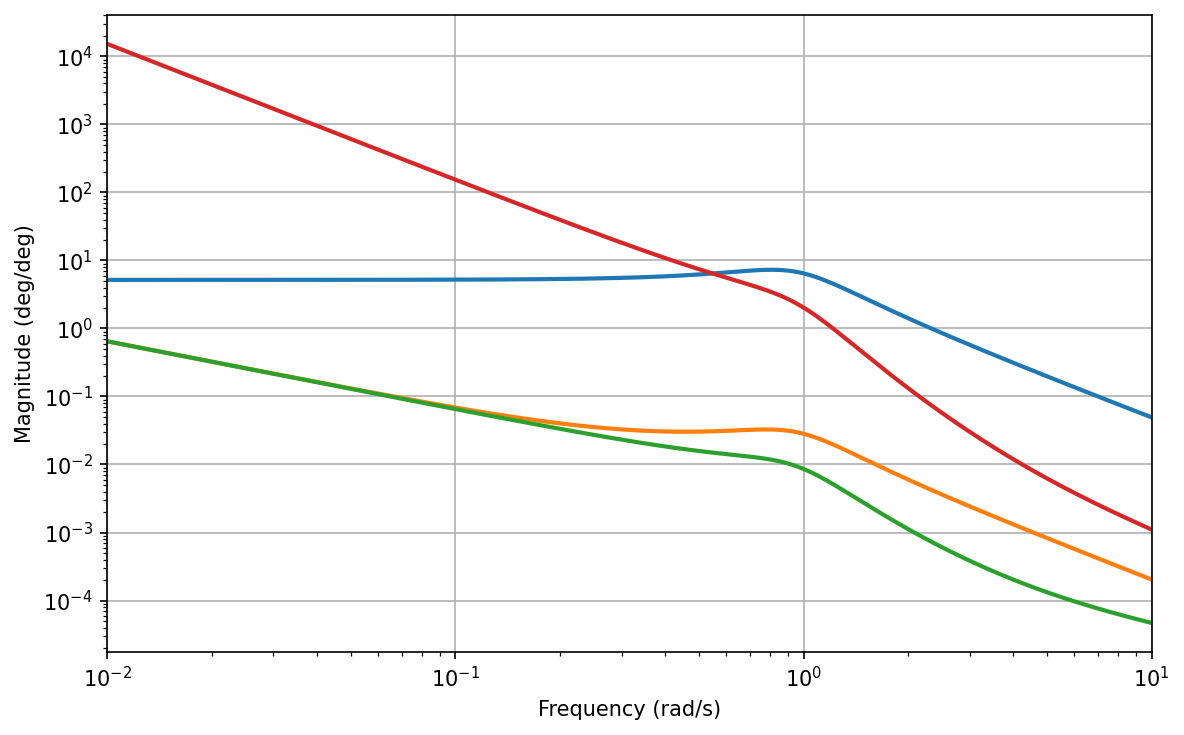

In [34]:
# Frequency response
freq = np.logspace(-2, 1, 400)
mag_wde,ph_wde,_ = ct.frequency_response(Gwde*np.pi/180, freq)  
mag_tde,ph_tde,_ = ct.frequency_response(Gtde*np.pi/180, freq)  
mag_gde,ph_gde,_ = ct.frequency_response(Ggde*np.pi/180, freq)
mag_hde,ph_hde,_ = ct.frequency_response(Ghde*np.pi/180, freq)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,sharex = True)
plt.loglog(freq, mag_wde)
plt.loglog(freq, mag_tde)
plt.loglog(freq, mag_gde)
plt.loglog(freq, mag_hde)

plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (deg/deg)')

plt.show()

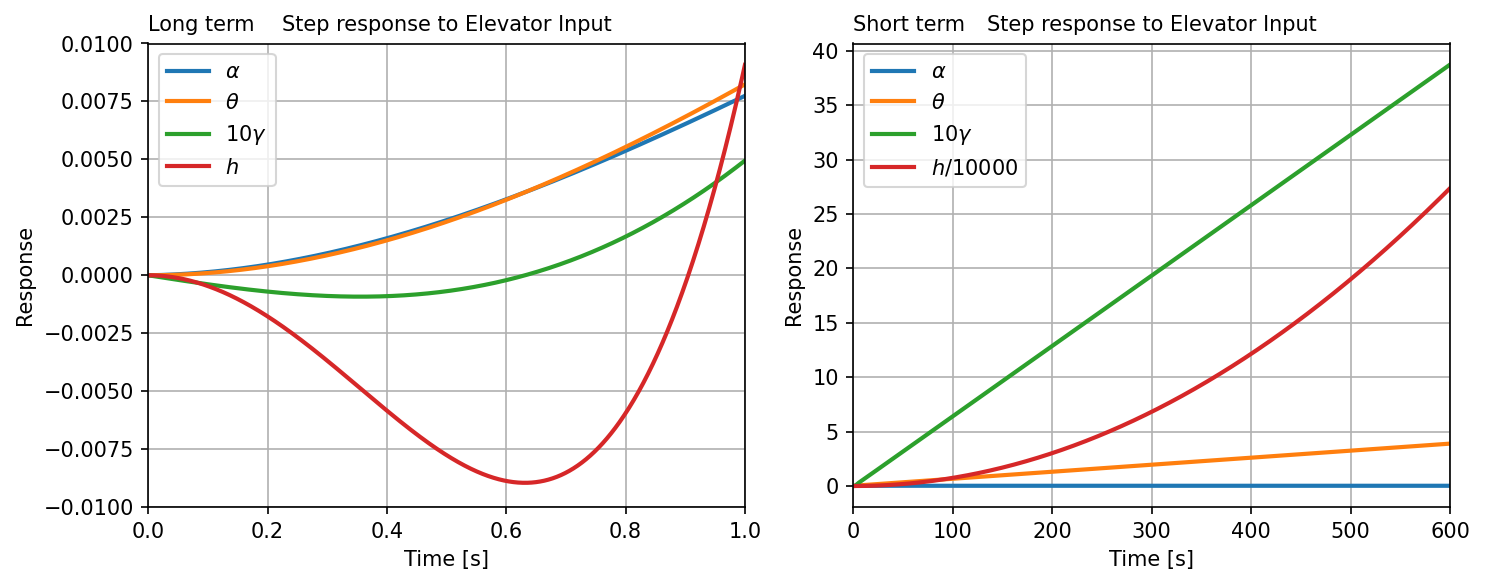

In [35]:
def resp(tf):
    t = np.linspace(0, tf, 1000)
    y_ude, t = cmat.step(cm.near_zero(Gude*elevator_gain), t)
    y_wde, t = cmat.step(cm.near_zero(Gwde*elevator_gain), t)
    y_tde, t = cmat.step(cm.near_zero(Gtde*elevator_gain), t)
    y_gde, t = cmat.step(cm.near_zero(Ggde*elevator_gain), t)
    y_hde, t = cmat.step(cm.near_zero(Ghde*elevator_gain), t)
    return y_ude, y_wde, y_tde, y_gde, y_hde, t

elevator_gain = -1*np.pi/180 # 1 deg up
fig, ax = plt.subplots(1,2,figsize=(10, 4),dpi=150)

tf = 1
y_ude, y_wde, y_tde, y_gde, y_hde, t = resp(tf)
#ax[0].plot(t, y_ude,label=r'$u$')
ax[0].plot(t, y_wde/U0,label=r'$\alpha$')
ax[0].plot(t, y_tde,label=r'$\theta$')
ax[0].plot(t, 10*y_gde,label=r'$10\gamma$')    
ax[0].plot(t, y_hde,label=r'$h$')    
ax[0].set_xlim(0,tf)
ax[0].legend()
ax[0].set_ylim(-.01,.01)
ax[0].grid(True)
ax[0].set_title('Step response to Elevator Input')
ax[0].set_title('Long term',loc='left')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Response')

tf = 600
y_ude, y_wde, y_tde, y_gde, y_hde, t = resp(tf)
#ax[1].plot(t, y_ude,label=r'$u$')
ax[1].plot(t, y_wde/U0,label=r'$\alpha$')
ax[1].plot(t, y_tde,label=r'$\theta$')
ax[1].plot(t, 10*y_gde,label=r'$10\gamma$')    
ax[1].plot(t, y_hde/10000,label=r'$h/10000$')    
ax[1].set_title('Step response to Elevator Input')
ax[1].set_title('Short term',loc='left')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Response')

ax[1].set_xlim(0,tf)
ax[1].legend()
#ax[1].set_ylim(-100,100)
ax[1].grid(True)
plt.savefig("./figs/B747_step.pdf", dpi=600)

<IPython.core.display.Math object>

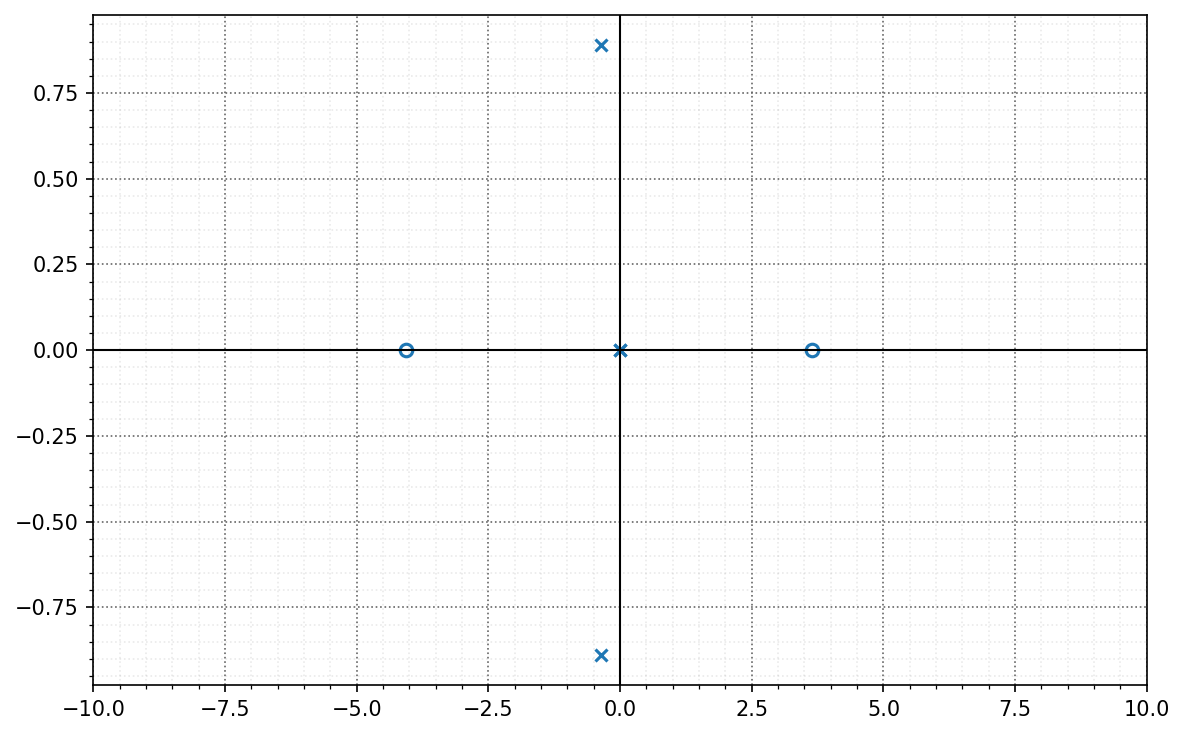

In [36]:
Ghde = cm.near_zero(Ghde)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150)
ct.pzmap(cm.near_zero(Ghde),ax=ax)
ax.set_xlim(-10,10)
bm.nicegrid(ax)
cm.show_tf_latex(Ghde,show=True)

In [37]:
np.roots(Ghde.num[0][0].flatten())

array([  -4.069,    3.640])

The lateral-direction equations of motion describing small perturbations about an 
equilibrium trim condition and referred to wind axes are given by the following state equations
$$
\begin{aligned}
& {\left[\begin{array}{c}
\dot{v} \\
\dot{p} \\
\dot{r} \\
\dot{\phi}
\end{array}\right]=\left[\begin{array}{cccc}
y_v & y_p & y_r & y_\phi \\
l_v & l_p & l_r & l_\phi \\
n_v\textbf{} & n_p & n_r & n_\phi \\
0 & 1 & 0 & 0
\end{array}\right]\left[\begin{array}{l}
v \\
p \\
r \\
\phi
\end{array}\right]+\left[\begin{array}{cc}
y_{\xi} & y_\zeta \\
l_{\xi} & l_\zeta \\
n_{\xi} & n_\zeta \\
0 & 0
\end{array}\right]\left[\begin{array}{l}
\xi \\
\zeta
\end{array}\right]}
\end{aligned}
$$
The solution of this equation produces two sets of four response transfer functions, one set describing motion in response to aileron input and a second set describing response to rudder input. As for the longitudinal response transfer functions, it is convenient to adopt a shorthand style of writing the transfer functions. The transfer functions describing response to aileron are conveniently written
$$
\begin{aligned}
& \frac{v(s)}{\xi(s)} \equiv \frac{N_\xi^v(s)}{\Delta(s)}=\frac{k_v\left(s+1 / T_{\beta_1}\right)\left(s+1 / T_{\beta_2}\right)}{\left(s+1 / T_s\right)\left(s+1 / T_{\mathrm{r}}\right)\left(s^2+2 \zeta_{\mathrm{d}} \omega_{\mathrm{d}} s+\omega_{\mathrm{d}}^2\right)} \\
& \frac{p(s)}{\xi(s)} \equiv \frac{N_\xi^p(s)}{\Delta(s)}=\frac{k_{p s}s\left (s^2+2 \zeta_\phi \omega_\phi s+\omega_\phi^2\right)}
{\left(s+1 / T_s\right)\left(s+1 / T_{\mathrm{r}}\right)\left(s^2+2 \zeta_{\mathrm{d}} \omega_{\mathrm{d}} s+\omega_{\mathrm{d}}^2\right)} \\
& \frac{r(s)}{\xi(s)} \equiv \frac{N_{\xi}^{r}(s)}{\Delta(s)}=\frac{k_r\left(s+1 / T_\psi\right)\left(s^2+2 \zeta_\psi \omega_\psi s+\omega_\psi^2\right)}{\left(s+1 / T_s\right)\left(s+1 / T_{\mathrm{r}}\right)\left(s^2+2 \zeta_{\mathrm{d}} \omega_{\mathrm{d}} s+\omega_{\mathrm{d}}^2\right)} \\
& \frac{\phi(s)}{\xi(s)} \equiv \frac{N_{\xi}^\phi(s)}{\Delta(s)}=\frac{k_\phi\left(s^2+2 \zeta_\phi \omega_\phi s+\omega_\phi^2\right)}{\left(s+1 / T_s\right)\left(s+1 / T_{\mathrm{r}}\right)\left(s^2+2 \zeta_{\mathrm{d}} \omega_{\mathrm{d}} s+\omega_{\mathrm{d}}^2\right)}
\end{aligned}
$$
and the transfer functions describing response to rudder are conveniently written
$$
\begin{aligned}
& \frac{v(s)}{\zeta(s)} \equiv \frac{N_\zeta^v(s)}{\Delta(s)}=\frac{k_v\left(s+1 / T_{\beta_1}\right)\left(s+1 / T_{\beta_2}\right)\left(s+1 / T_{\beta_3}\right)}{\left(s+1 / T_s\right)\left(s+1 / T_{\mathrm{r}}\right)\left(s^2+2 \zeta_{\mathrm{d}} \omega_{\mathrm{d}} s+\omega_{\mathrm{d}}^2\right)} \\
& \frac{p(s)}{\zeta(s)} \equiv \frac{N_\zeta^p(s)}{\Delta(s)}=\frac{k_p s\left(s+1 / T_{\phi_1}\right)\left(s+1 / T_{\phi_2}\right)}{\left(s+1 / T_{\mathrm{s}}\right)\left(s+1 / T_{\mathrm{r}}\right)\left(s^2+2 \zeta_{\mathrm{d}} \omega_{\mathrm{d}} s+\omega_{\mathrm{d}}^2\right)} \\
& \frac{r(s)}{\zeta(s)} \equiv \frac{N_\zeta^\tau(s)}{\Delta(s)}=\frac{k_r\left(s+1 / T_\psi\right)\left(s^2+2 \zeta_\psi \omega_\psi s+\omega_\psi^2\right)}{\left(s+1 / T_{\mathrm{s}}\right)\left(s+1 / T_{\mathrm{r}}\right)\left(s^2+2 \zeta_{\mathrm{d}} \omega_{\mathrm{d}} s+\omega_{\mathrm{d}}^2\right)} \\
& \frac{\phi(s)}{\zeta(s)} \equiv \frac{N_\zeta^\phi(s)}{\Delta(s)}=\frac{k_\phi\left(s+1 / T_{\phi_1}\right)\left(s+1 / T_{\phi_2}\right)}{\left(s+1 / T_{\mathrm{s}}\right)\left(s+1 / T_{\mathrm{r}}\right)\left(s^2+2 \zeta_{\mathrm{d}} \omega_{\mathrm{d}} s+\omega_{\mathrm{d}}^2\right)}
\end{aligned}
$$


The equations of motion and aerodynamic data for the Douglas DC-8 aircraft were obtained from Teper (1969). At the flight condition of interest the aircraft has a total weight of 190000 lb and is flying at Mach 0.44 at an altitude of 15000 ft. The source data are referenced to aircraft body axes and for the purposes of this illustration they have been converted to a wind axes reference
%using the transformations given in Appendices 7 and 8 . 
The equations of motion, referred to wind axes and quoted in terms of concise derivatives are, in state space format,
$$
\left[\begin{array}{c}
\dot{v} \\
\dot{p} \\
\dot{r} \\
\dot{\phi}
\end{array}\right]=\left[\begin{array}{cccc}
-0.1008 & 0 & -468.2 & 32.2 \\
-0.00579 & -1.232 & 0.397 & 0 \\
0.00278 & -0.0346 & -0.257 & 0 \\
0 & 1 & 0 & 0
\end{array}\right]\left[\begin{array}{l}
v \\
p \\
r \\
\phi
\end{array}\right]+\left[\begin{array}{cc}
0 & 13.48416 \\
-1.62 & 0.392 \\
-0.01875 & -0.864 \\
0 & 0
\end{array}\right]
\left[\begin{array}{l}
\xi \\
\zeta
\end{array}\right]
\begin{array}{l}
\text{Aileron}\\
\text{Rudder}
\end{array}
$$



Since it is useful to have the transfer function describing sideslip angle $\beta$ as well as sideslip velocity $v$, the output equation is augmented as 
$$
\left[\begin{array}{c}
v \\
p \\
r \\
\phi \\
\beta
\end{array}\right]=\left[\begin{array}{cccc}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
0.00214 & 0 & 0 & 0
\end{array}\right]\left[\begin{array}{c}
v \\
p \\
r \\
\phi
\end{array}\right]
$$
First, the transfer functions describing response to aileron
$$
\begin{aligned}
& \frac{v(s)}{\xi(s)}=\frac{8.779(s+0.197)(s-7.896)}{(s+0.0065)(s+1.329)\left(s^2+0.254 s+1.433\right)} \mathrm{ft} / \mathrm{s} / \mathrm{rad} \\
& \frac{p(s)}{\xi(s)}=\frac{-1.62 s\left(\mathrm{~s}^2+0.362 s+1.359\right)}{(s+0.0065)(s+1.329)\left(s^2+0.254 \mathrm{~s}+1.433\right)} \mathrm{rad} / \mathrm{s} / \mathrm{rad}(\mathrm{deg} / \mathrm{s} / \mathrm{deg}) \\
& \frac{r(s)}{\xi(s)}=\frac{-0.0188(s+1.59)\left(\mathrm{s}^2-3.246 \mathrm{~s}+4.982\right)}{(s+0.0065)(s+1.329)\left(s^2+0.254 \mathrm{~s}+1.433\right)} \mathrm{rad} / \mathrm{s} / \mathrm{rad}(\mathrm{deg} / \mathrm{s} / \mathrm{deg}) \\
& \frac{\phi(s)}{\xi(s)}=\frac{-1.62\left(\mathrm{~s}^2+0.362 s+1.359\right)}{(s+0.0065)(\mathrm{s}+1.329)\left(s^2+0.254 \mathrm{~s}+1.433\right)} \mathrm{rad} / \mathrm{rad}(\mathrm{deg} / \mathrm{deg}) \\
& \frac{\beta(s)}{\xi(s)}=\frac{0.0188(s+0.197)(s-7.896)}{(s+0.0065)(s+1.329)\left(s^2+0.254 s+1.433\right)} \mathrm{rad} / \mathrm{rad}(\mathrm{deg} / \mathrm{deg})
\end{aligned}
$$
and second, the transfer functions describing response to rudder
$$
\begin{aligned}
& \frac{v(s)}{\zeta(s)}=\frac{13.484(s-0.0148)(s+1.297)(s+30.207)}{(s+0.0065)(s+1.329)\left(s^2+0.254 s+1.433\right)} \mathrm{ft} / \mathrm{s} / \mathrm{rad} \\
& \frac{p(s)}{\zeta(s)}=\frac{0.392 s(s+1.85)(s-2.566)}{(s+0.0065)(s+1.329)\left(s^2+0.254 s+1.433\right)} \mathrm{rad} / \mathrm{s} / \mathrm{rad}(\mathrm{deg} / \mathrm{s} / \mathrm{deg}) \\
& \frac{r(s)}{\zeta(s)}=\frac{-0.864(s+1.335)\left(\mathrm{s}^2-0.03 \mathrm{~s}+0.109\right)}{(s+0.0065)(s+1.329)\left(s^2+0.254 s+1.433\right)} \mathrm{rad} / \mathrm{s} / \mathrm{rad}(\mathrm{deg} / \mathrm{s} / \mathrm{deg}) \\
& \frac{\phi(s)}{\zeta(s)}=\frac{0.392 s(s+1.85)(s-2.566)}{(s+0.0065)(s+1.329)\left(s^2+0.254 s+1.433\right)} \mathrm{rad} / \mathrm{rad}(\mathrm{deg} / \mathrm{deg}) \\
& \frac{\beta(s)}{\zeta(s)}=\frac{0.029(s-0.0148)(\mathrm{s}+1.297)(s+30.207)}{(s+0.0065)(s+1.329)\left(s^2+0.254 \mathrm{~s}+1.433\right)} \mathrm{rad} / \mathrm{rad}(\mathrm{deg} / \mathrm{deg})
\end{aligned}
$$
The characteristic equation is given by equating the denominator to zero
$$
\Delta(s)=(s+0.0065)(s+1.329)\left(s^2+0.254 s+1.433\right)=0
$$
The first real root describes the spiral mode with time constant
$$
T_{\mathrm{s}}=\frac{1}{0.0065} \cong 154 \mathrm{~s}
$$
the second real root describes the roll subsidence mode with time constant
$$
T_{\mathrm{r}}=\frac{1}{1.329}=0.75 \mathrm{~s}
$$
and the pair of complex roots describe the oscillatory dutch roll mode with characteristics
$$
\begin{aligned}
\text { damping ratio } \zeta_{\mathrm{d}} & =0.11 \\
\text { undamped natural frequency } \omega_{\mathrm{d}} & =1.2 \mathrm{rad} / \mathrm{s}
\end{aligned}
$$
Since both real roots are negative and the pair of complex roots have negative real parts then the mode characteristics indicate the airframe to be aerodynamically stable. 

In [38]:
A = np.array([
    [-0.1008, 0, -468.2, 32.2],
    [-0.00579, -1.232, 0.397, 0],
    [0.00278, -0.0346, -0.257, 0],
    [0, 1, 0, 0]
])
B = np.array([
    [0, 13.48416],
    [-1.62, 0.392],
    [-0.01875, -0.864],
    [0, 0]
])

C = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.00214, 0.0, 0.0, 0.0]
])

Meas = ['v', 'p', 'r', 'phi', 'Beta']
Cont = ['aileron', 'rudder']
G = {}
for i, m in enumerate(Meas):
    for j, c in enumerate(Cont):
        print(i, m, j, c)   
        G[m,c] = ct.ss2tf(A, B[:, j], C[i, :], 0)


0 v 0 aileron
0 v 1 rudder
1 p 0 aileron
1 p 1 rudder
2 r 0 aileron
2 r 1 rudder
3 phi 0 aileron
3 phi 1 rudder
4 Beta 0 aileron
4 Beta 1 rudder


0 0 v aileron
1 0 p aileron
2 0 r aileron
3 0 phi aileron
4 0 Beta aileron
0 1 v rudder
1 1 p rudder
2 1 r rudder
3 1 phi rudder
4 1 Beta rudder


/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/scipy/signal/_lti_conversion.py:74: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


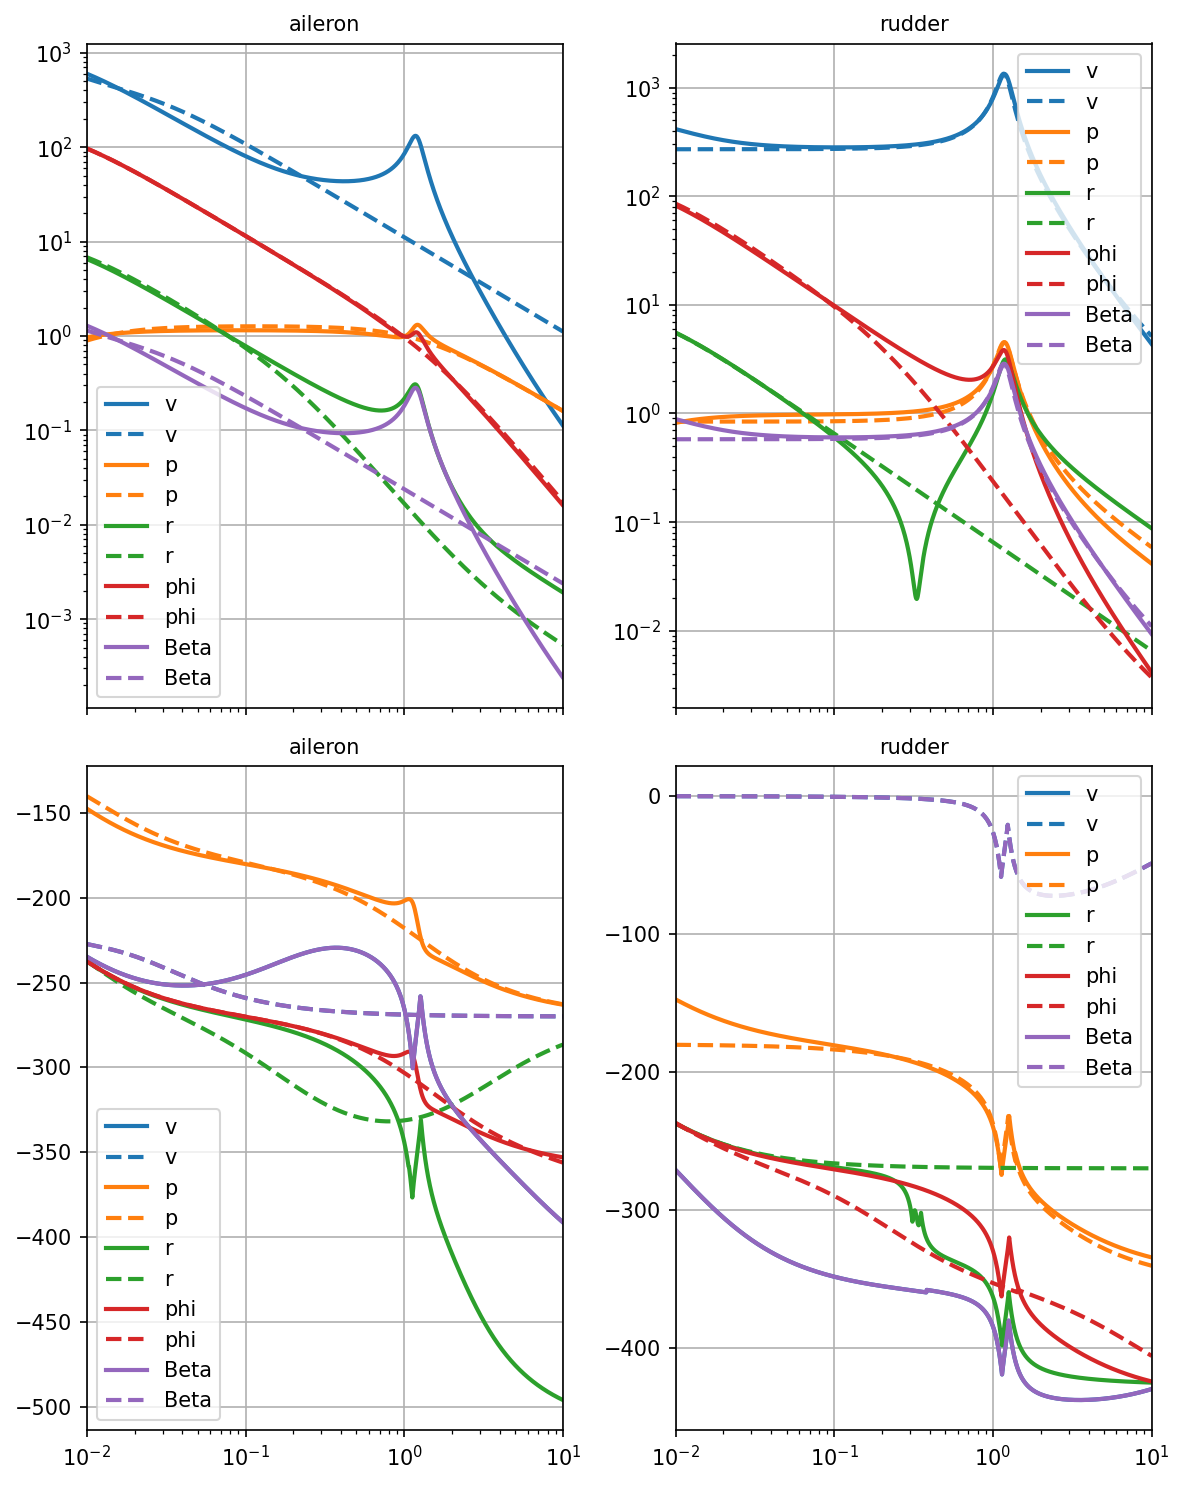

In [39]:
omega = np.logspace(-2,1,1000)
fig, ax = plt.subplots(2,2,figsize=(8, 10),dpi=150,sharex = True)
for j, c in enumerate(Cont):
    for i, m in enumerate(Meas):
        print(i, j, m, c)   
        Gf = G[m,c](complex(0,1)*omega)
        Gbal = cm.balred(G[m,c],2)
        Gbalf = Gbal(complex(0,1)*omega)
        ax[0,j].loglog(omega, np.abs(Gf), label=m, color='C'+str(i))
        ax[1,j].semilogx(omega, np.unwrap(cm.wrap_phase_neg(np.angle(Gf)*cm.r2d)), label=m, color='C'+str(i))
        ax[0,j].loglog(omega, np.abs(Gbalf), '--', label=m, color='C'+str(i))
        ax[1,j].semilogx(omega, np.unwrap(cm.wrap_phase_neg(np.angle(Gbalf)*cm.r2d)), '--', label=m, color='C'+str(i))
        ax[0,j].set_title(c)
        ax[0,j].grid(True)
        ax[0,j].legend()
        ax[1,j].set_title(c)
        ax[1,j].grid(True)
        ax[1,j].legend()

# Show the plot
plt.tight_layout()
plt.show()

0 0 v aileron
1 0 p aileron
2 0 r aileron
3 0 phi aileron
4 0 Beta aileron
0 1 v rudder
1 1 p rudder
2 1 r rudder
3 1 phi rudder
4 1 Beta rudder


/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/control/timeresp.py:1082: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(


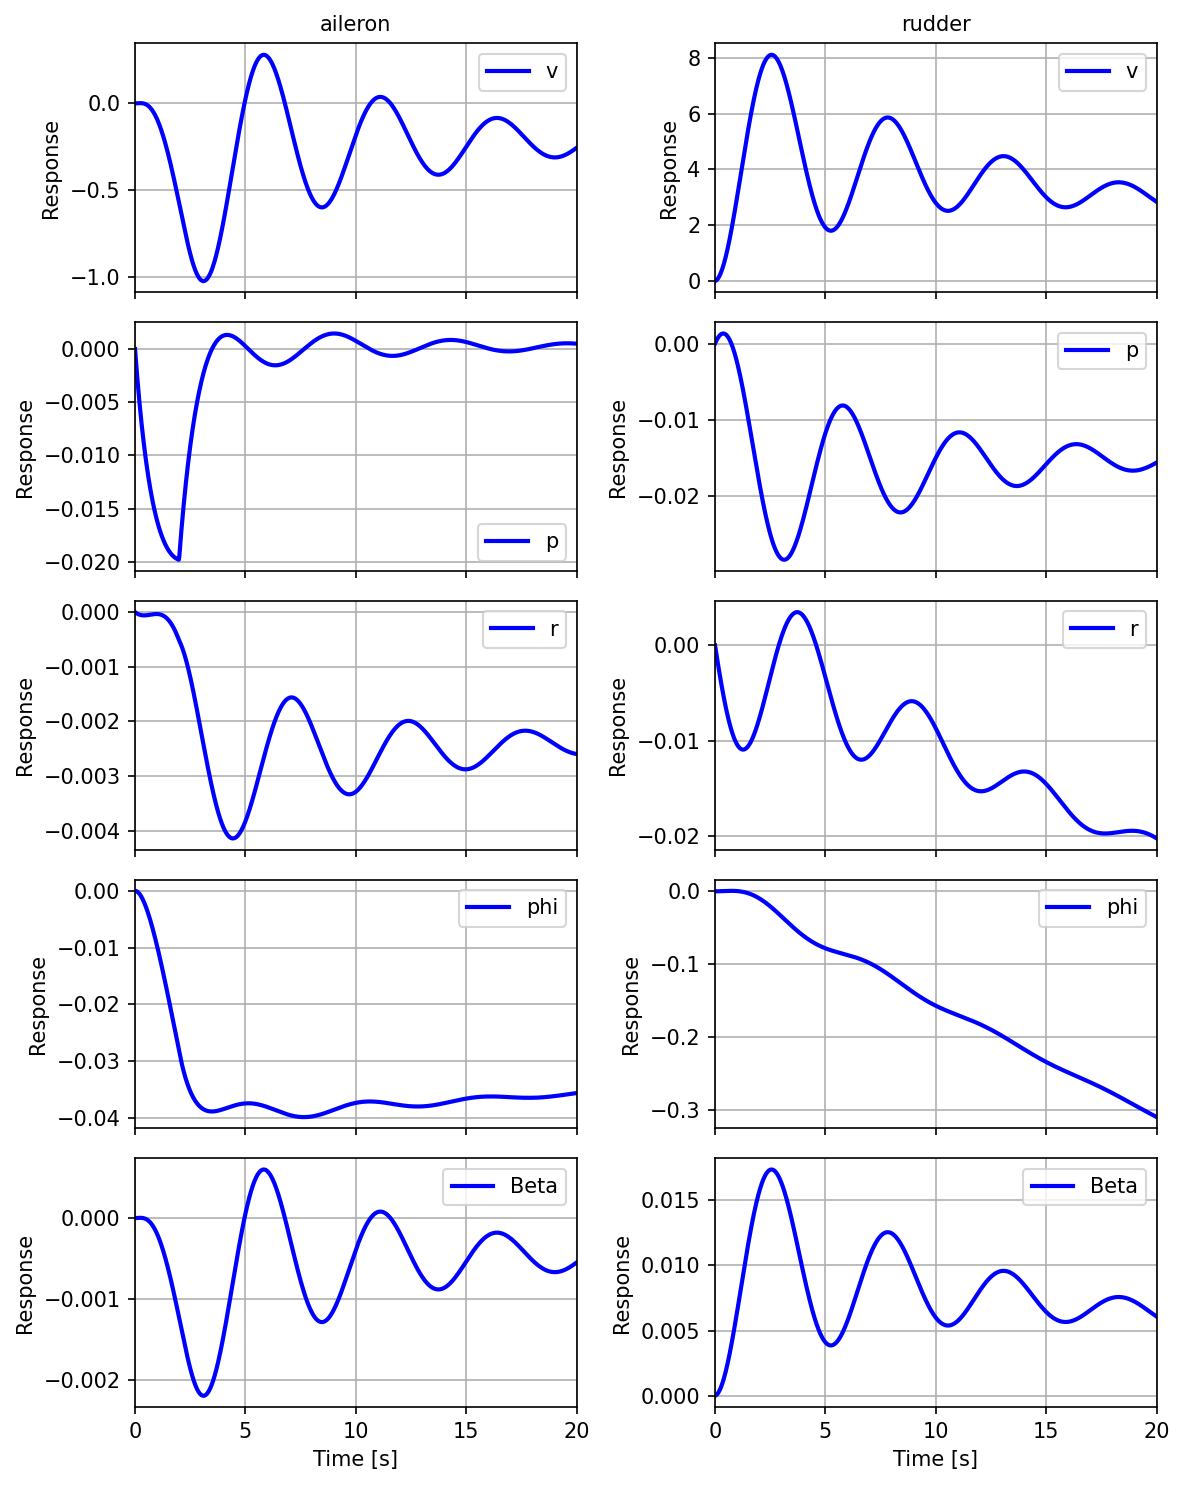

In [40]:
t = np.linspace(0,20,1000)
U = np.zeros_like(t)
U [t < 2] = 1  # pulse for 2 seconds

fig, ax = plt.subplots(5,2,figsize=(8, 10),dpi=150,sharex = True)
for j, c in enumerate(Cont):
    for i, m in enumerate(Meas):
        print(i, j, m, c)
        Gtf = cm.near_zero(G[m,c])   
        if c == 'aileron':
            yout = cmat.lsim(Gtf*np.pi/180,T=t,U=U)
        else:
            yout = cmat.step(Gtf*np.pi/180,T=t)
        ax[i][j].plot(t,yout[0],label=m,c='b')
        ax[0][j].set_title(c)
        ax[i][j].grid(True)
        ax[i][j].legend()
        ax[i][j].set_xlim(0,20)
        #ax[i][j].set_ylim(-.1,.1)
        ax[i][j].set_ylabel('Response')
        ax[4][j].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()